In [12]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import kagglehub

# 1. Загрузка датасета
path = "C:/Users/Nikita/.cache/kagglehub/datasets/michelheusser/handwritten-digits-and-operators/versions/9"
print("Изначальный путь к датасету:", path)

dataset_dir = path
while True:
    items = os.listdir(dataset_dir)
    dirs = [d for d in items if os.path.isdir(os.path.join(dataset_dir, d))]
    if len(dirs) == 1:
        dataset_dir = os.path.join(dataset_dir, dirs[0])
    else:
        break

print("Рабочая папка с датасетом:", dataset_dir)

IMG_SIZE = 32
MAX_IMAGES_PER_CLASS = 5000 

def load_and_preprocess_data(data_path, img_size, max_per_class):
    images = []
    labels = []
    class_names = []
    image_class_names = []        # имя папки для каждой картинки
    
    classes = [d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))]
    classes.sort()
    
    for label, class_name in enumerate(classes):
        class_names.append(class_name)
        class_path = os.path.join(data_path, class_name)
        
        count = 0
        for img_name in os.listdir(class_path):
            if count >= max_per_class:
                break
                
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE) 
            
            if img is not None:
                img = cv2.resize(img, (img_size, img_size))
                img = img / 255.0
                images.append(img)
                labels.append(label)
                image_class_names.append(class_name)
                count += 1
                
    return np.array(images), np.array(labels), class_names, image_class_names


# Загружаем данные
X, y, class_names, image_class_names = load_and_preprocess_data(dataset_dir, IMG_SIZE, MAX_IMAGES_PER_CLASS)

X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

# Разделение на train/test
X_train, X_test, y_train, y_test, train_class_names, test_class_names = train_test_split(
    X, y, image_class_names, test_size=0.2, random_state=42
)

# One-hot encoding
NUM_CLASSES = len(class_names)
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_test_cat = to_categorical(y_test, NUM_CLASSES)

print(f"Количество классов: {NUM_CLASSES}")
print("Порядок классов:", class_names)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# Функция для отрисовки графиков и лог-файл (словарь)
results_log = {}

def plot_history(history, title):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f'{title} - Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} - Loss')
    plt.legend()
    plt.show()

Изначальный путь к датасету: C:/Users/Nikita/.cache/kagglehub/datasets/michelheusser/handwritten-digits-and-operators/versions/9
Рабочая папка с датасетом: C:/Users/Nikita/.cache/kagglehub/datasets/michelheusser/handwritten-digits-and-operators/versions/9\CompleteImages\All data (Compressed)
Количество классов: 16
Порядок классов: ['%', '+', '-', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '[', ']', '_']
Train shape: (64000, 32, 32, 1), Test shape: (16000, 32, 32, 1)


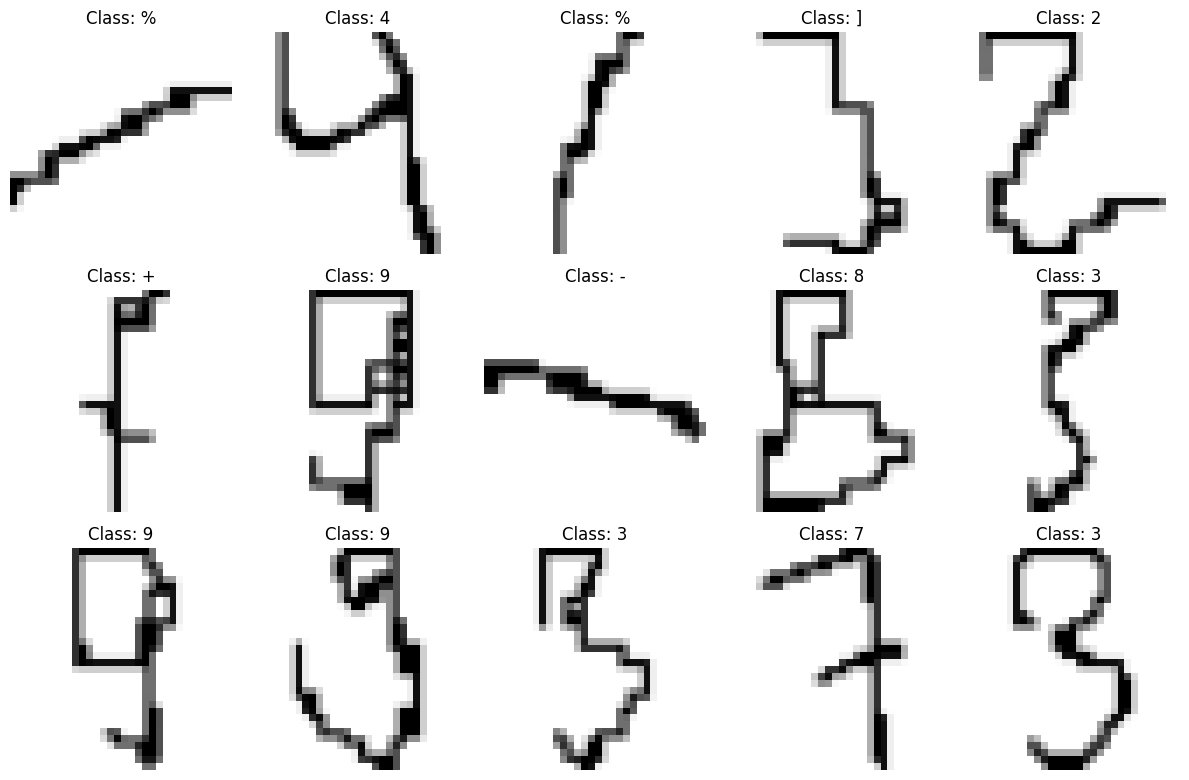

In [14]:
plt.figure(figsize=(12, 8))

for i in range(15):
    plt.subplot(3, 5, i + 1)
    img = X_train[i].squeeze()
    plt.imshow(img, cmap='gray')
    
    real_class_name = train_class_names[i]
    
    plt.title(f"Class: {real_class_name}")
    plt.axis('off')

plt.tight_layout()
plt.show()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,920 (1.21 MB)

 Trainable params: 315,920 (1.21 MB)

 Non-trainable params: 0 (0.00 B)


--- Обучение базовой модели ---
Epoch 1/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.8911 - loss: 0.3513 - val_accuracy: 0.9525 - val_loss: 0.1408
Epoch 2/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9638 - loss: 0.1077 - val_accuracy: 0.9606 - val_loss: 0.1160
Epoch 3/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9729 - loss: 0.0766 - val_accuracy: 0.9732 - val_loss: 0.0814
Epoch 4/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9783 - loss: 0.0602 - val_accuracy: 0.9709 - val_loss: 0.0796
Epoch 5/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9801 - loss: 0.0529 - val_accuracy: 0.9753 - val_loss: 0.0707
Epoch 6/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9828 - loss: 0.0454 - val_accuracy: 0.9778 - val_loss: 0.0681
Epoch 7/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9848 - loss: 0.0401 - val_accuracy: 0.9794 - val_loss: 0.0667
Epoch 8/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/

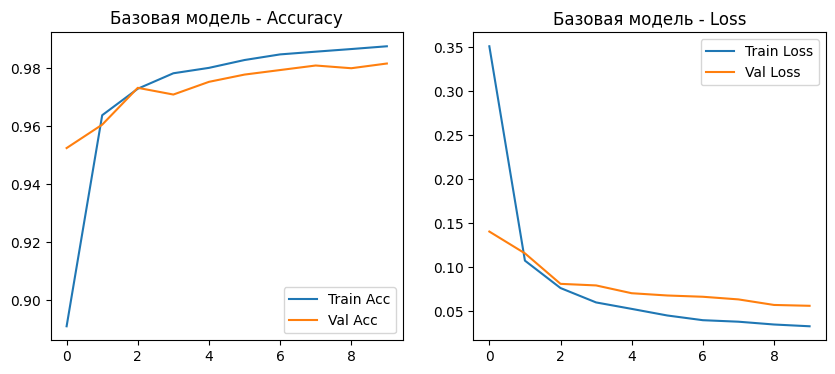

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Предсказанный класс стороннего изображения: %


In [15]:
# 1. Базовая модель
base_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

base_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 1.2 Вывод архитектуры
base_model.summary()

# Обучение
print("\n--- Обучение базовой модели ---")
history_base = base_model.fit(X_train, y_train_cat, epochs=10, batch_size=32, validation_data=(X_test, y_test_cat), verbose=1)

# Сохранение результатов
loss, acc = base_model.evaluate(X_test, y_test_cat, verbose=0)
results_log['Base Model'] = acc
plot_history(history_base, "Базовая модель")

# 1.4 Проверка
try:
    test_img = 'my_digit.png'
    img_ext = cv2.imread(test_img, cv2.IMREAD_GRAYSCALE)
    img_ext = cv2.resize(img_ext, (IMG_SIZE, IMG_SIZE)) / 255.0
    img_ext = img_ext.reshape(1, IMG_SIZE, IMG_SIZE, 1)
    pred = base_model.predict(img_ext)
    print(f"Предсказанный класс стороннего изображения: {class_names[np.argmax(pred)]}")
except:
    print(f"Сторонний файл {test_img} не найден. Для проверки загрузите файл.")

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 64)     │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 628,496 (2.40 MB)

 Trainable params: 628,496 (2.40 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 39s 19ms/step - accuracy: 0.9040 - loss: 0.3060 - val_accuracy: 0.9617 - val_loss: 0.1256
Epoch 2/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 36s 18ms/step - accuracy: 0.9700 - loss: 0.0917 - val_accuracy: 0.9762 - val_loss: 0.0754
Epoch 3/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - accuracy: 0.9772 - loss: 0.0657 - val_accuracy: 0.9729 - val_loss: 0.0840
Epoch 4/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 37s 19ms/step - accuracy: 0.9816 - loss: 0.0540 - val_accuracy: 0.9803 - val_loss: 0.0608
Epoch 5/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 37s 19ms/step - accuracy: 0.9833 - loss: 0.0473 - val_accuracy: 0.9818 - val_loss: 0.0538
Epoch 6/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 36s 18ms/step - accuracy: 0.9847 - loss: 0.0426 - val_accuracy: 0.9824 - val_loss: 0.0512
Epoch 7/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 35s 18ms/step - accuracy: 0.9863 - loss: 0.0385 - val_accuracy: 0.9829 - val_loss: 0.0524
Epoch 8/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 38s 19ms/step - accuracy: 0.9868 -

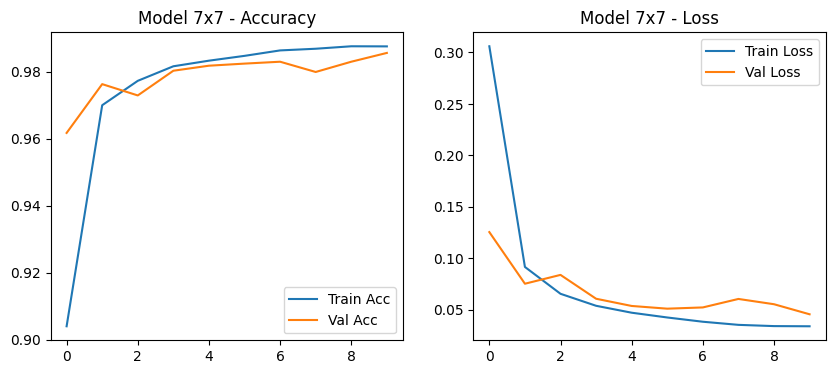

Точность Model 7x7: 0.9856


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 578,576 (2.21 MB)

 Trainable params: 578,576 (2.21 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - accuracy: 0.9043 - loss: 0.3060 - val_accuracy: 0.9622 - val_loss: 0.1291
Epoch 2/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9710 - loss: 0.0862 - val_accuracy: 0.9753 - val_loss: 0.0764
Epoch 3/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 25s 12ms/step - accuracy: 0.9791 - loss: 0.0616 - val_accuracy: 0.9731 - val_loss: 0.0830
Epoch 4/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 25s 12ms/step - accuracy: 0.9826 - loss: 0.0494 - val_accuracy: 0.9824 - val_loss: 0.0502
Epoch 5/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 25s 12ms/step - accuracy: 0.9847 - loss: 0.0429 - val_accuracy: 0.9793 - val_loss: 0.0618
Epoch 6/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 25s 12ms/step - accuracy: 0.9856 - loss: 0.0395 - val_accuracy: 0.9834 - val_loss: 0.0592
Epoch 7/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 25s 12ms/step - accuracy: 0.9876 - loss: 0.0337 - val_accuracy: 0.9847 - val_loss: 0.0553
Epoch 8/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 30s 15ms/step - accuracy: 0.9877 -

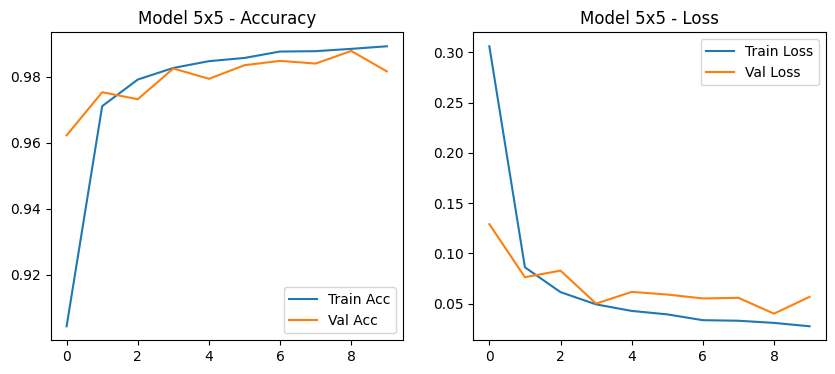

Точность Model 5x5: 0.9816


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,808 (2.08 MB)

 Trainable params: 545,808 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 25s 12ms/step - accuracy: 0.9107 - loss: 0.2841 - val_accuracy: 0.9629 - val_loss: 0.1163
Epoch 2/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9729 - loss: 0.0829 - val_accuracy: 0.9769 - val_loss: 0.0713
Epoch 3/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9804 - loss: 0.0571 - val_accuracy: 0.9744 - val_loss: 0.0739
Epoch 4/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9832 - loss: 0.0468 - val_accuracy: 0.9809 - val_loss: 0.0548
Epoch 5/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.9850 - loss: 0.0410 - val_accuracy: 0.9809 - val_loss: 0.0527
Epoch 6/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.9866 - loss: 0.0356 - val_accuracy: 0.9763 - val_loss: 0.0721
Epoch 7/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9874 - loss: 0.0331 - val_accuracy: 0.9806 - val_loss: 0.0609
Epoch 8/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9886 - l

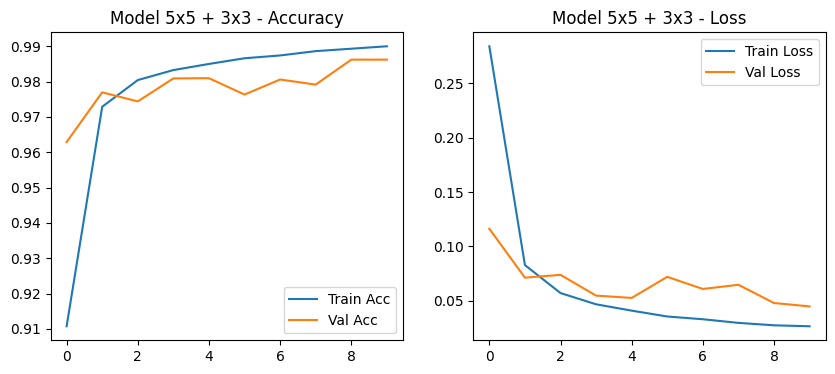

Точность Model 5x5 + 3x3: 0.9862


<Sequential name=sequential_6, built=True>

In [16]:
def build_and_train_model(name, model):
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    model.summary()
    hist = model.fit(X_train, y_train_cat, epochs=10, batch_size=32, validation_data=(X_test, y_test_cat), verbose=1)
    loss, acc = model.evaluate(X_test, y_test_cat, verbose=1)
    results_log[name] = acc
    plot_history(hist, name)
    print(f"Точность {name}: {acc:.4f}")
    return model

# 2.1 Фильтры 7x7
model_7x7 = models.Sequential([
    layers.Conv2D(32, (7, 7), activation='relu', padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (7, 7), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
])
build_and_train_model("Model 7x7", model_7x7)

# 2.2 Фильтры 5x5
model_5x5 = models.Sequential([
    layers.Conv2D(32, (5, 5), activation='relu', padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (5, 5), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
])
build_and_train_model("Model 5x5", model_5x5)

# 2.3 Фильтр 5x5 затем 3x3
model_5x5_3x3 = models.Sequential([
    layers.Conv2D(32, (5, 5), activation='relu', padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
])
build_and_train_model("Model 5x5 + 3x3", model_5x5_3x3)

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 30, 30, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 666,512 (2.54 MB)

 Trainable params: 666,512 (2.54 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 32s 15ms/step - accuracy: 0.8934 - loss: 0.3442 - val_accuracy: 0.9587 - val_loss: 0.1308
Epoch 2/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - accuracy: 0.9641 - loss: 0.1109 - val_accuracy: 0.9661 - val_loss: 0.1005
Epoch 3/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 31s 15ms/step - accuracy: 0.9732 - loss: 0.0775 - val_accuracy: 0.9732 - val_loss: 0.0777
Epoch 4/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 31s 15ms/step - accuracy: 0.9786 - loss: 0.0611 - val_accuracy: 0.9764 - val_loss: 0.0694
Epoch 5/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 31s 15ms/step - accuracy: 0.9813 - loss: 0.0520 - val_accuracy: 0.9794 - val_loss: 0.0592
Epoch 6/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 33s 16ms/step - accuracy: 0.9836 - loss: 0.0447 - val_accuracy: 0.9743 - val_loss: 0.0735
Epoch 7/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 30s 15ms/step - accuracy: 0.9848 - loss: 0.0407 - val_accuracy: 0.9788 - val_loss: 0.0668
Epoch 8/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 30s 15ms/step - accuracy: 0.9855 -

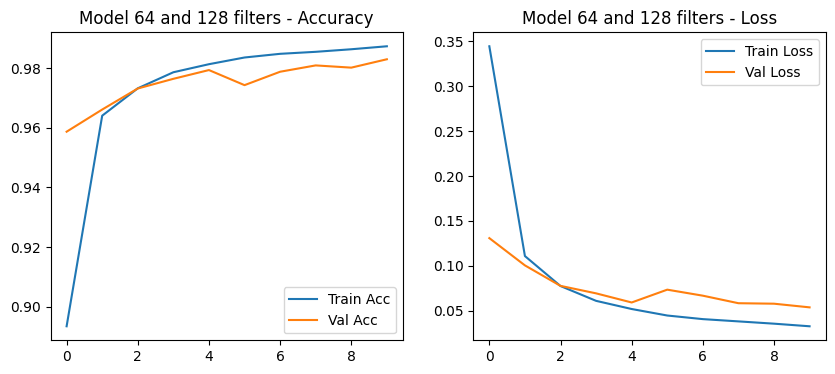

Точность Model 64 and 128 filters: 0.9830


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 30, 30, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 15, 15, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 13, 13, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 6, 6, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 16)             │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,168 (301.44 KB)

 Trainable params: 77,168 (301.44 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8596 - loss: 0.4579 - val_accuracy: 0.9350 - val_loss: 0.2024
Epoch 2/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9492 - loss: 0.1552 - val_accuracy: 0.9575 - val_loss: 0.1341
Epoch 3/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9640 - loss: 0.1067 - val_accuracy: 0.9640 - val_loss: 0.1049
Epoch 4/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9710 - loss: 0.0820 - val_accuracy: 0.9709 - val_loss: 0.0861
Epoch 5/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9763 - loss: 0.0674 - val_accuracy: 0.9688 - val_loss: 0.0882
Epoch 6/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9788 - loss: 0.0589 - val_accuracy: 0.9768 - val_loss: 0.0671
Epoch 7/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9810 - loss: 0.0517 - val_accuracy: 0.9781 - val_loss: 0.0658
Epoch 8/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9829 - loss: 0.0460 - 

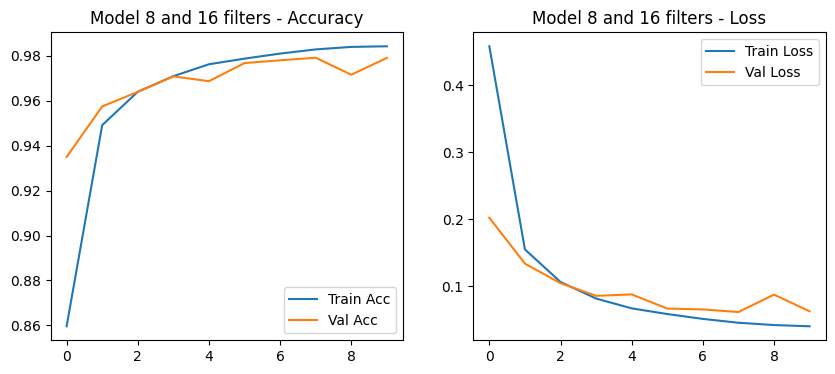

Точность Model 8 and 16 filters: 0.9791


<Sequential name=sequential_8, built=True>

In [17]:
# 3.1 Фильтры 64 и 128
model_64_128 = models.Sequential([
    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
])
build_and_train_model("Model 64 and 128 filters", model_64_128)

# 3.2 Фильтры 8 и 16
model_8_16 = models.Sequential([
    layers.Conv2D(8, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
])
build_and_train_model("Model 8 and 16 filters", model_8_16)

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 16)             │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591,472 (2.26 MB)

 Trainable params: 591,472 (2.26 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 36s 17ms/step - accuracy: 0.9247 - loss: 0.2366 - val_accuracy: 0.9741 - val_loss: 0.0772
Epoch 2/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 34s 17ms/step - accuracy: 0.9781 - loss: 0.0636 - val_accuracy: 0.9837 - val_loss: 0.0487
Epoch 3/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 35s 17ms/step - accuracy: 0.9834 - loss: 0.0461 - val_accuracy: 0.9811 - val_loss: 0.0536
Epoch 4/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 35s 17ms/step - accuracy: 0.9859 - loss: 0.0383 - val_accuracy: 0.9840 - val_loss: 0.0424
Epoch 5/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 35s 17ms/step - accuracy: 0.9877 - loss: 0.0332 - val_accuracy: 0.9871 - val_loss: 0.0381
Epoch 6/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 35s 17ms/step - accuracy: 0.9884 - loss: 0.0305 - val_accuracy: 0.9877 - val_loss: 0.0350
Epoch 7/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 35s 17ms/step - accuracy: 0.9897 - loss: 0.0269 - val_accuracy: 0.9826 - val_loss: 0.0458
Epoch 8/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 35s 18ms/step - accuracy: 0.9898 -

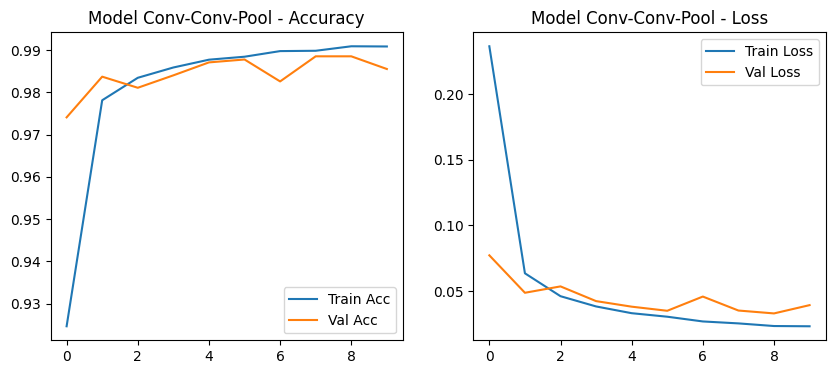

Точность Model Conv-Conv-Pool: 0.9855


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 15, 15, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │       200,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 16)             │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,464 (829.94 KB)

 Trainable params: 212,464 (829.94 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8854 - loss: 0.3734 - val_accuracy: 0.9526 - val_loss: 0.1484
Epoch 2/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9632 - loss: 0.1119 - val_accuracy: 0.9649 - val_loss: 0.1051
Epoch 3/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9749 - loss: 0.0762 - val_accuracy: 0.9735 - val_loss: 0.0817
Epoch 4/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9789 - loss: 0.0605 - val_accuracy: 0.9757 - val_loss: 0.0765
Epoch 5/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9826 - loss: 0.0496 - val_accuracy: 0.9787 - val_loss: 0.0626
Epoch 6/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9842 - loss: 0.0436 - val_accuracy: 0.9834 - val_loss: 0.0486
Epoch 7/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9851 - loss: 0.0402 - val_accuracy: 0.9803 - val_loss: 0.0626
Epoch 8/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9871 - loss: 0.0343 - 

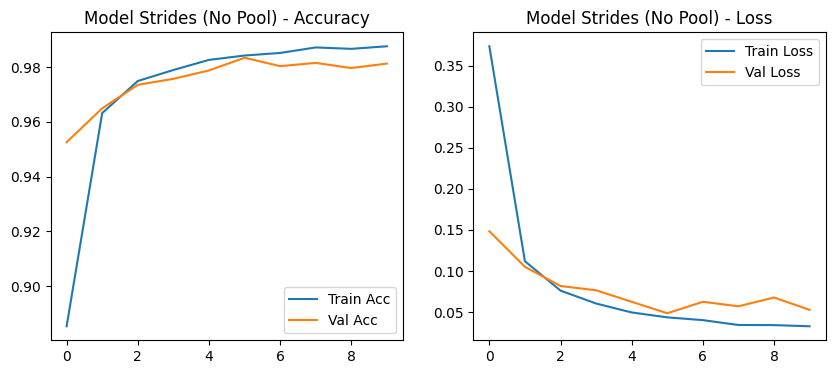

Точность Model Strides (No Pool): 0.9812


<Sequential name=sequential_10, built=True>

In [18]:
# 4.1 Чередование (Conv-Conv-Pool)
model_alt_1 = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
])
build_and_train_model("Model Conv-Conv-Pool", model_alt_1)

# 4.2 Свертки с шагом stride=2 вместо MaxPooling
model_alt_2 = models.Sequential([
    layers.Conv2D(32, (3, 3), strides=2, activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.Conv2D(32, (3, 3), strides=2, activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
])
build_and_train_model("Model Strides (No Pool)", model_alt_2)

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_26 (Conv2D)              │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 16)             │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161,296 (630.06 KB)

 Trainable params: 160,848 (628.31 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 27s 12ms/step - accuracy: 0.8633 - loss: 0.4421 - val_accuracy: 0.8208 - val_loss: 0.5725
Epoch 2/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.9409 - loss: 0.1847 - val_accuracy: 0.5599 - val_loss: 1.8377
Epoch 3/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.9566 - loss: 0.1357 - val_accuracy: 0.6611 - val_loss: 1.6826
Epoch 4/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.9633 - loss: 0.1141 - val_accuracy: 0.5840 - val_loss: 2.0933
Epoch 5/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.9678 - loss: 0.0977 - val_accuracy: 0.9379 - val_loss: 0.1824
Epoch 6/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.9714 - loss: 0.0846 - val_accuracy: 0.8275 - val_loss: 0.6561
Epoch 7/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.9736 - loss: 0.0763 - val_accuracy: 0.9645 - val_loss: 0.1124
Epoch 8/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.9766 -

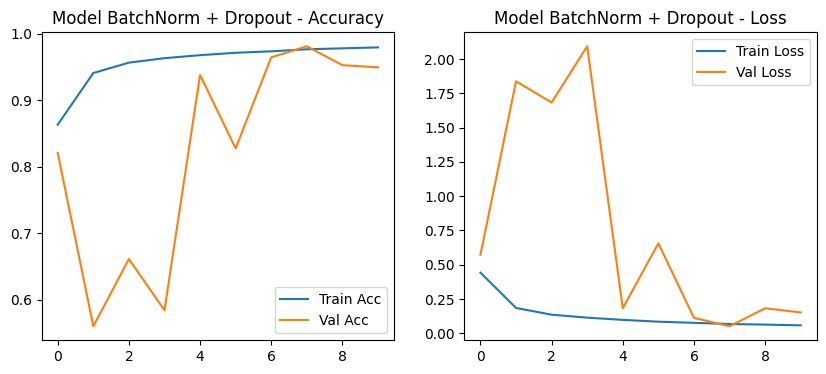

Точность Model BatchNorm + Dropout: 0.9495


In [19]:
# 5. Батч-нормализация и Dropout
model_bn_drop = models.Sequential([
    layers.Conv2D(32, (3, 3), input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), 
    layers.Dense(NUM_CLASSES, activation='softmax')
])
best_model_candidate = build_and_train_model("Model BatchNorm + Dropout", model_bn_drop)

In [115]:
print("\n--- Итоговое сравнение моделей ---")
if not results_log:
    print("Лог результатов пуст. Нечего сравнивать.")
else:
    #Сортировка и вывод всех результатов
    sorted_results = sorted(results_log.items(), key=lambda item: item[1], reverse=True)
    
    for name, acc in sorted_results:
        print(f"{name:25} | Точность: {acc:.4f}")

    #Автоматический выбор лучшей модели по названию
    best_model_name = sorted_results[0][0]
    print(f"\n Лучшая модель по метрике Accuracy: {best_model_name}")

    #Сопоставление названия с объектом модели
    model_map = {
        "Base Model": base_model,
        "Model 7x7": model_7x7,
        "Model 5x5": model_5x5,
        "Model 5x5 + 3x3": model_5x5_3x3,
        "Model 64 and 128 filters": model_64_128,
        "Model 8 and 16 filters": model_8_16,
        "Model Conv-Conv-Pool": model_alt_1,
        "Model Strides (No Pool)": model_alt_2,
        "Model BatchNorm + Dropout": model_bn_drop
    }

    best_model_obj = model_map.get(best_model_name)

    if best_model_obj:
        #Сохранение
        save_name = 'best_cnn_model.h5'
        best_model_obj.save(save_name)
        print(f" Модель '{best_model_name}' сохранена как '{save_name}'")


--- Итоговое сравнение моделей ---
Model 5x5 + 3x3           | Точность: 0.9862
Model 7x7                 | Точность: 0.9856
Model Conv-Conv-Pool      | Точность: 0.9855
Model 64 and 128 filters  | Точность: 0.9830
Base Model                | Точность: 0.9816
Model 5x5                 | Точность: 0.9816
Model Strides (No Pool)   | Точность: 0.9812
Model 8 and 16 filters    | Точность: 0.9791
Model BatchNorm + Dropout | Точность: 0.9495

 Лучшая модель по метрике Accuracy: Model 5x5 + 3x3
 Модель 'Model 5x5 + 3x3' сохранена как 'best_cnn_model.h5'



 Результат 'best_cnn_model' (Gamma: 0.21):
   → Предсказано: 2 (77.0%)


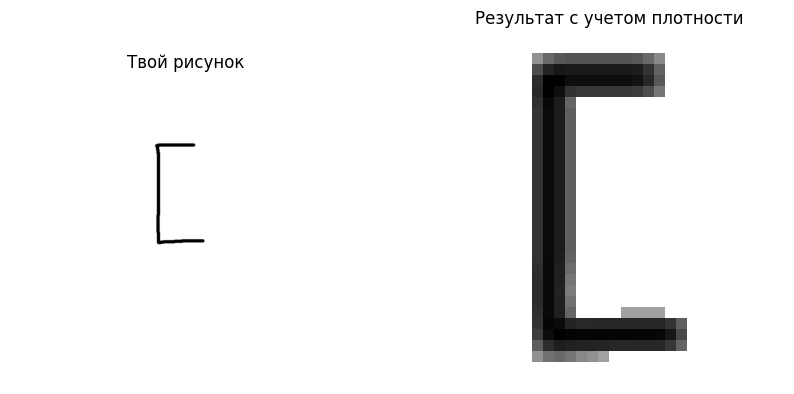

In [114]:
from tensorflow.keras.models import load_model

def preprocess_for_inference(image_path, img_size=32, invert=False, gamma=1.0):

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Не удалось прочитать: {image_path}")
    
    original = img.copy()
    
    if invert:
        img = cv2.bitwise_not(img)
    
    #Центрирование и кроп
    mask = cv2.bitwise_not(img) 
    coords = cv2.findNonZero(mask)
    
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        padding = int(max(w, h) * 0.15)
        x_start, y_start = max(0, x - padding), max(0, y - padding)
        x_end = min(img.shape[1], x + w + padding)
        y_end = min(img.shape[0], y + h + padding)
        img = img[y_start:y_end, x_start:x_end]

    #Делаем квадратный белый фон
    h, w = img.shape[:2]
    side = max(h, w)
    square = np.full((side, side), 255, dtype=np.uint8) 
    ax, ay = (side - w) // 2, (side - h) // 2
    square[ay:ay+h, ax:ax+w] = img
    
    #Ресайз
    img_resized = cv2.resize(square, (img_size, img_size), interpolation=cv2.INTER_AREA)
    
    #Легкое размытие
    img_resized = cv2.GaussianBlur(img_resized, (3, 3), 0)
    
    #Инвертируем, чтобы гамма работала именно на цифру, а не на фон
    img_inv = cv2.bitwise_not(img_resized)
    img_float = img_inv.astype(np.float32) / 255.0
    img_corrected = np.power(img_float, gamma) # Применяем плотность
    
    img_final = cv2.bitwise_not((img_corrected * 255).astype(np.uint8))
    img_normalized = img_final.astype(np.float32) / 255.0
    
    
    img_input = img_normalized.reshape(1, img_size, img_size, 1)
    
    return original, img_final, img_input

def predict_custom_image(image_path, model_name='best_cnn_model', invert=True, gamma=1.0): 
    model_path = f'saved_models/{model_name}.h5'
    
    if not os.path.exists(model_path):
        if os.path.exists(f'{model_name}.h5'):
            model_path = f'{model_name}.h5'
        else:
            print(f"❌ Модель {model_name} не найдена!")
            return
    
    model = load_model(model_path)
    
    try:
        #Передаем gamma в функцию предобработки
        original_img, processed_img, img_input = preprocess_for_inference(image_path, invert=invert, gamma=gamma)
    except Exception as e:
        print(f"Ошибка: {e}")
        return
    
    preds = model.predict(img_input, verbose=0)
    class_idx = np.argmax(preds)
    confidence = np.max(preds) * 100
    
    print(f"\n Результат '{model_name}' (Gamma: {gamma}):")
    print(f"   → Предсказано: {class_names[class_idx]} ({confidence:.1f}%)")
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(original_img, cmap='gray')
    axes[0].set_title("Твой рисунок")
    axes[0].axis('off')
    
    axes[1].imshow(processed_img, cmap='gray')
    axes[1].set_title("Результат с учетом плотности")
    axes[1].axis('off')
    
    plt.show()

# Запуск
YOUR_IMAGE_NAME = 'left_bracket.png' 
CHOSEN_MODEL = 'best_cnn_model' 

if os.path.exists(YOUR_IMAGE_NAME):
    
    predict_custom_image(YOUR_IMAGE_NAME, model_name=CHOSEN_MODEL, invert=False, gamma=0.21) 
else:
    print(f"Файл {YOUR_IMAGE_NAME} не найден")

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


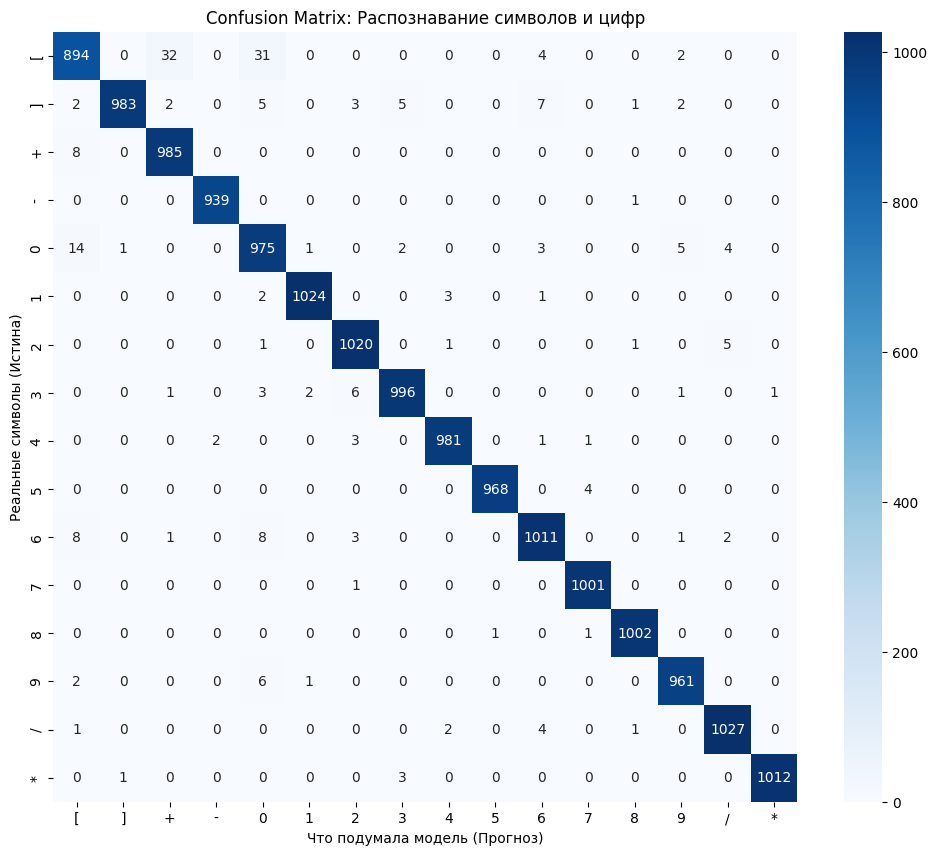

In [22]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Получаем предсказания модели на тестовой выборке
y_pred_probs = best_model_obj.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

if len(y_test.shape) > 1 and y_test.shape[1] > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test

# 2. Список имен классов 
my_class_names = ['[', ']', '+', '-', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '/', '*']

# 3. Создаем матрицу ошибок
cm = confusion_matrix(y_true, y_pred_classes)

# 4. Визуализация через Seaborn
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=my_class_names, 
            yticklabels=my_class_names)

plt.title('Confusion Matrix: Распознавание символов и цифр')
plt.ylabel('Реальные символы (Истина)')
plt.xlabel('Что подумала модель (Прогноз)')
plt.show()